# K-Means Modeling and Customer Segment Interpretation

This notebook evaluates several K-Means cluster counts, selects a practical segmentation solution, and interprets the resulting customer segments.

The input is the model-ready feature matrix prepared in the preprocessing notebook. Because this is an unsupervised learning project, the evaluation does not use accuracy. Instead, the notebook uses inertia, silhouette score, Davies-Bouldin score, cluster balance, and business interpretability.

In [1]:
from pathlib import Path
import time

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from IPython.display import display
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.metrics import (
    calinski_harabasz_score,
    davies_bouldin_score,
    silhouette_score,
)

pd.set_option("display.max_columns", 120)
pd.set_option("display.width", 140)
pd.set_option("display.float_format", "{:,.4f}".format)

sns.set_theme(style="whitegrid", context="notebook")

RANDOM_STATE = 42
SILHOUETTE_SAMPLE_SIZE = 10_000

In [2]:
project_root = Path.cwd()

if project_root.name == "notebooks":
    project_root = project_root.parent

processed_data_dir = project_root / "data" / "processed"
figures_dir = project_root / "reports" / "figures"

processed_data_dir.mkdir(parents=True, exist_ok=True)
figures_dir.mkdir(parents=True, exist_ok=True)

model_ready_path = processed_data_dir / "customer_features_model_ready.csv"
preprocessed_path = processed_data_dir / "customer_features_preprocessed.csv"
base_features_path = processed_data_dir / "customer_features_base.csv"

print("Project root:", project_root)
print("Model-ready feature file exists:", model_ready_path.exists())
print("Preprocessed feature file exists:", preprocessed_path.exists())
print("Base feature file exists:", base_features_path.exists())

Project root: d:\Workspace\Tugas_IMV_Laboratory_Recruitment\imv-customer-segmentation-kmeans
Model-ready feature file exists: True
Preprocessed feature file exists: True
Base feature file exists: True


## Load Modeling Inputs

The K-Means model uses the scaled model-ready feature matrix. The base customer feature table is loaded only for business interpretation after cluster labels are created.

In [3]:
model_ready_features = pd.read_csv(model_ready_path)
preprocessed_features = pd.read_csv(preprocessed_path)
base_customer_features = pd.read_csv(base_features_path)

print("Model-ready shape:", model_ready_features.shape)
print("Preprocessed shape:", preprocessed_features.shape)
print("Base customer feature shape:", base_customer_features.shape)

display(model_ready_features.head())

Model-ready shape: (93350, 11)
Preprocessed shape: (93350, 11)
Base customer feature shape: (93350, 23)


,customer_unique_id,log_recency_days,log_order_count,log_total_payment_value,log_avg_payment_installments,log_total_product_count,log_freight_to_payment_ratio,log_avg_delivery_days,avg_review_score,late_delivery_rate,has_review_score
0,0000366f3b9a7992bf8c76cfdf3221e2,-0.4790,-0.1702,0.2883,1.7903,-0.2408,-1.0368,-0.6991,0.6581,-0.2995,0.0806
1,0000b849f77a49e4a4ce2b2a4ca5be3f,-0.4508,-0.1702,-1.7193,-0.8543,-0.2408,0.8280,-1.6093,-0.1245,-0.2995,0.0806
2,0000f46a3911fa3c0805444483337064,1.2083,-0.1702,-0.3224,1.7903,-0.2408,-0.0193,1.4326,-0.9071,-0.2995,0.0806
3,0000f6ccb0745a6a4b88665a16c9f078,0.6543,-0.1702,-1.1514,0.7568,-0.2408,1.5674,1.0345,-0.1245,-0.2995,0.0806
4,0004aac84e0df4da2b147fca70cf8255,0.5378,-0.1702,0.6909,1.3484,-0.2408,-1.0254,0.3745,0.6581,-0.2995,0.0806


In [4]:
feature_columns = [column for column in model_ready_features.columns if column != "customer_unique_id"]

input_checks = pd.DataFrame(
    [
        {
            "check": "model_ready_rows",
            "value": len(model_ready_features),
            "passed": len(model_ready_features) == 93_350,
        },
        {
            "check": "model_ready_columns",
            "value": model_ready_features.shape[1],
            "passed": model_ready_features.shape[1] == 11,
        },
        {
            "check": "duplicate_customer_unique_id",
            "value": int(model_ready_features["customer_unique_id"].duplicated().sum()),
            "passed": model_ready_features["customer_unique_id"].duplicated().sum() == 0,
        },
        {
            "check": "missing_values",
            "value": int(model_ready_features.isna().sum().sum()),
            "passed": model_ready_features.isna().sum().sum() == 0,
        },
        {
            "check": "model_feature_count",
            "value": len(feature_columns),
            "passed": len(feature_columns) == 10,
        },
    ]
)

display(input_checks)

if not input_checks["passed"].all():
    raise ValueError("At least one modeling input check failed.")

,check,value,passed
0,model_ready_rows,93350,True
1,model_ready_columns,11,True
2,duplicate_customer_unique_id,0,True
3,missing_values,0,True
4,model_feature_count,10,True


In [5]:
X = model_ready_features[feature_columns].copy()

display(X.describe().T[["mean", "std", "min", "50%", "max"]])


,mean,std,min,50%,max
log_recency_days,0.0000,1.0000,-4.8430,0.2429,1.5145
log_order_count,0.0000,1.0000,-0.1702,-0.1702,26.9462
log_total_payment_value,0.0000,1.0000,-5.8491,-0.0492,5.9288
log_avg_payment_installments,-0.0000,1.0000,-2.0731,-0.1414,3.5866
log_total_product_count,0.0000,1.0000,-0.2408,-0.2408,17.7420
log_freight_to_payment_ratio,-0.0000,1.0000,-1.8553,-0.1595,4.9066
log_avg_delivery_days,-0.0000,1.0000,-3.3171,-0.0079,4.8628
avg_review_score,-0.0000,1.0000,-2.4723,0.6581,0.6581
late_delivery_rate,0.0000,1.0000,-0.2995,-0.2995,3.3752
has_review_score,0.0000,1.0000,-12.4020,0.0806,0.0806


## K-Means Evaluation Metrics

This project compares multiple cluster counts using several metrics:

| Metric                  | Better Direction                                        | Meaning                                                                            |
| ----------------------- | ------------------------------------------------------- | ---------------------------------------------------------------------------------- |
| Inertia                 | Lower is better, but must be checked with elbow pattern | Measures how compact the clusters are.                                             |
| Silhouette Score        | Higher is better                                        | Measures whether customers are closer to their own cluster than to other clusters. |
| Davies-Bouldin Score    | Lower is better                                         | Measures cluster separation and compactness.                                       |
| Calinski-Harabasz Score | Higher is better                                        | Measures separation between clusters relative to compactness within clusters.      |
| Cluster Balance         | Not too extreme                                         | Checks whether one cluster dominates almost all customers.                         |

Accuracy is not used because K-Means is unsupervised and there is no true label for each customer segment.

In [6]:
k_values = list(range(2, 9))

evaluation_rows = []
labels_by_k = {}

for k in k_values:
    start_time = time.time()

    kmeans = KMeans(
        n_clusters=k,
        random_state=RANDOM_STATE,
        n_init=20,
    )
    labels = kmeans.fit_predict(X)
    fit_seconds = time.time() - start_time

    cluster_counts = pd.Series(labels).value_counts().sort_index()
    cluster_shares = cluster_counts / cluster_counts.sum()

    silhouette = silhouette_score(
        X,
        labels,
        sample_size=SILHOUETTE_SAMPLE_SIZE,
        random_state=RANDOM_STATE,
    )
    davies_bouldin = davies_bouldin_score(X, labels)
    calinski_harabasz = calinski_harabasz_score(X, labels)

    evaluation_rows.append(
        {
            "k": k,
            "inertia": kmeans.inertia_,
            "silhouette_sample_10000": silhouette,
            "davies_bouldin": davies_bouldin,
            "calinski_harabasz": calinski_harabasz,
            "min_cluster_size": int(cluster_counts.min()),
            "max_cluster_size": int(cluster_counts.max()),
            "min_cluster_share": float(cluster_shares.min()),
            "max_cluster_share": float(cluster_shares.max()),
            "fit_seconds": fit_seconds,
        }
    )

    labels_by_k[k] = labels

evaluation_metrics = pd.DataFrame(evaluation_rows)
evaluation_metrics["inertia_drop_from_previous_pct"] = (
    evaluation_metrics["inertia"].shift(1).sub(evaluation_metrics["inertia"])
    / evaluation_metrics["inertia"].shift(1)
    * 100
)

display(evaluation_metrics.round(4))

,k,inertia,silhouette_sample_10000,davies_bouldin,calinski_harabasz,min_cluster_size,max_cluster_size,min_cluster_share,max_cluster_share,fit_seconds,inertia_drop_from_previous_pct
0,2,"797,442.7123",0.5333,0.8562,"15,926.7562",3128,90222,0.0335,0.9665,2.3451,NaN
1,3,"673,825.7037",0.4071,1.0524,"17,986.7111",3119,82819,0.0334,0.8872,0.4943,15.5017
2,4,"573,359.7378",0.2049,1.4242,"19,544.2550",3119,42112,0.0334,0.4511,0.5888,14.9098
3,5,"482,475.1088",0.2121,1.1868,"21,815.1740",603,41369,0.0065,0.4432,0.7599,15.8512
4,6,"433,225.7284",0.2074,1.1743,"21,558.1812",603,32947,0.0065,0.3529,0.8067,10.2077
5,7,"394,600.7946",0.1981,1.2388,"21,246.2049",603,28575,0.0065,0.3061,0.8225,8.9157
6,8,"360,709.6027",0.2091,1.1999,"21,174.7548",603,27940,0.0065,0.2993,1.1250,8.5887


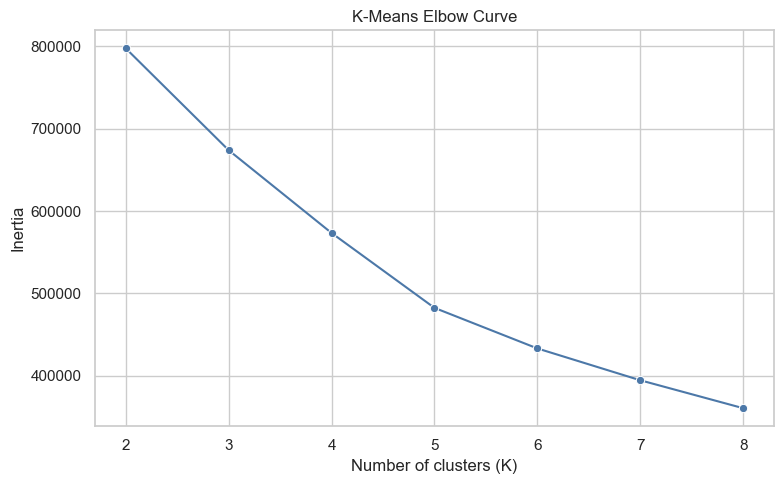

In [7]:
plt.figure(figsize=(8, 5))
sns.lineplot(
    data=evaluation_metrics,
    x="k",
    y="inertia",
    marker="o",
    color="#4C78A8",
)
plt.title("K-Means Elbow Curve")
plt.xlabel("Number of clusters (K)")
plt.ylabel("Inertia")
plt.xticks(evaluation_metrics["k"])
plt.tight_layout()
plt.savefig(figures_dir / "kmeans_elbow_curve.png", dpi=150, bbox_inches="tight")
plt.show()

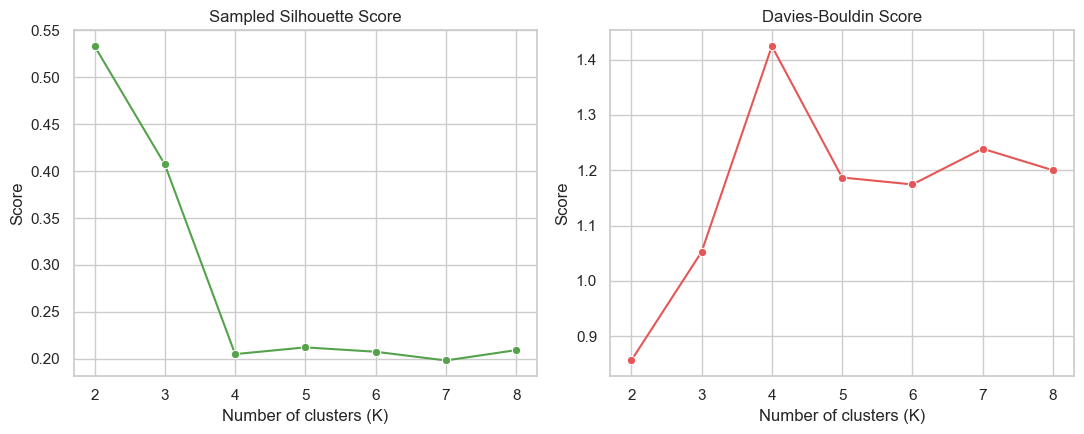

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4.5))

sns.lineplot(
    data=evaluation_metrics,
    x="k",
    y="silhouette_sample_10000",
    marker="o",
    ax=axes[0],
    color="#54A24B",
)
axes[0].set_title("Sampled Silhouette Score")
axes[0].set_xlabel("Number of clusters (K)")
axes[0].set_ylabel("Score")
axes[0].set_xticks(evaluation_metrics["k"])

sns.lineplot(
    data=evaluation_metrics,
    x="k",
    y="davies_bouldin",
    marker="o",
    ax=axes[1],
    color="#E45756",
)
axes[1].set_title("Davies-Bouldin Score")
axes[1].set_xlabel("Number of clusters (K)")
axes[1].set_ylabel("Score")
axes[1].set_xticks(evaluation_metrics["k"])

plt.tight_layout()
plt.savefig(figures_dir / "kmeans_metric_comparison.png", dpi=150, bbox_inches="tight")
plt.show()

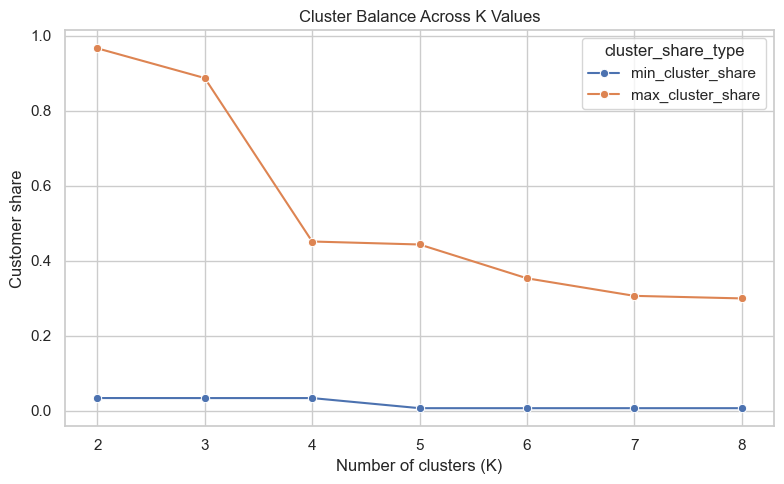

In [9]:
balance_plot_data = evaluation_metrics.melt(
    id_vars="k",
    value_vars=["min_cluster_share", "max_cluster_share"],
    var_name="cluster_share_type",
    value_name="cluster_share",
)

plt.figure(figsize=(8, 5))
sns.lineplot(
    data=balance_plot_data,
    x="k",
    y="cluster_share",
    hue="cluster_share_type",
    marker="o",
)
plt.title("Cluster Balance Across K Values")
plt.xlabel("Number of clusters (K)")
plt.ylabel("Customer share")
plt.xticks(evaluation_metrics["k"])
plt.tight_layout()
plt.savefig(figures_dir / "kmeans_cluster_balance.png", dpi=150, bbox_inches="tight")
plt.show()

## Final Cluster Count Selection

The selected cluster count is K=4.

K=2 has the highest silhouette score, but it is too imbalanced because more than 96% of customers fall into one cluster. K=3 is also still highly imbalanced. K=5 and above create a very small cluster dominated by review availability, which is informative but less practical as the main segmentation for this assignment.

K=4 gives a better balance between metric evaluation, cluster size distribution, and business interpretability.

In [10]:
selected_k = 4

selection_notes = pd.DataFrame(
    [
        {
            "k": 2,
            "decision": "Not selected",
            "reason": "Highest silhouette, but one cluster contains about 96.65% of customers.",
        },
        {
            "k": 3,
            "decision": "Not selected",
            "reason": "Still too imbalanced because one cluster contains about 88.72% of customers.",
        },
        {
            "k": 4,
            "decision": "Selected",
            "reason": "More balanced and easier to interpret as practical customer segments.",
        },
        {
            "k": "5-8",
            "decision": "Not selected",
            "reason": "Creates very small review-availability-driven clusters and adds complexity for this assignment scope.",
        },
    ]
)

display(selection_notes)
print("Selected K:", selected_k)

,k,decision,reason
0,2,Not selected,"Highest silhouette, but one cluster contains a..."
1,3,Not selected,Still too imbalanced because one cluster conta...
2,4,Selected,More balanced and easier to interpret as pract...
3,5-8,Not selected,Creates very small review-availability-driven ...


Selected K: 4


In [11]:
final_kmeans = KMeans(
    n_clusters=selected_k,
    random_state=RANDOM_STATE,
    n_init=20,
)

final_cluster_labels = final_kmeans.fit_predict(X)

final_cluster_counts = (
    pd.Series(final_cluster_labels, name="cluster")
    .value_counts()
    .sort_index()
    .rename("customer_count")
    .reset_index()
)
final_cluster_counts["customer_share"] = (
    final_cluster_counts["customer_count"] / final_cluster_counts["customer_count"].sum()
)

display(final_cluster_counts)

,cluster,customer_count,customer_share
0,0,42112,0.4511
1,1,40718,0.4362
2,2,7401,0.0793
3,3,3119,0.0334


In [21]:
customer_segments = model_ready_features[["customer_unique_id"]].copy()
customer_segments["cluster"] = final_cluster_labels

segment_name_map = {
    0: "Low-value one-time customers with high freight burden",
    1: "Higher-value installment one-time customers",
    2: "Delayed and dissatisfied customers",
    3: "Repeat and broader-basket customers",
}

segment_short_name_map = {
    0: "Low-value / freight-sensitive",
    1: "Higher-value / installment",
    2: "Delayed / dissatisfied",
    3: "Repeat / broader basket",
}

customer_segments["segment_name"] = customer_segments["cluster"].map(segment_name_map)
customer_segments["segment_short_name"] = customer_segments["cluster"].map(segment_short_name_map)

display(customer_segments.head())
display(customer_segments["segment_name"].value_counts())

,customer_unique_id,cluster,segment_name,segment_short_name
0,0000366f3b9a7992bf8c76cfdf3221e2,1,Higher-value installment one-time customers,Higher-value / installment
1,0000b849f77a49e4a4ce2b2a4ca5be3f,0,Low-value one-time customers with high freight...,Low-value / freight-sensitive
2,0000f46a3911fa3c0805444483337064,1,Higher-value installment one-time customers,Higher-value / installment
3,0000f6ccb0745a6a4b88665a16c9f078,0,Low-value one-time customers with high freight...,Low-value / freight-sensitive
4,0004aac84e0df4da2b147fca70cf8255,1,Higher-value installment one-time customers,Higher-value / installment


segment_name
Low-value one-time customers with high freight burden    42112
Higher-value installment one-time customers              40718
Delayed and dissatisfied customers                        7401
Repeat and broader-basket customers                       3119
Name: count, dtype: int64

## Business Segment Profile

The cluster labels are interpreted using the original customer-level features, not the scaled feature values. Median is used because e-commerce behavior features are skewed.

In [13]:
business_profile_columns = [
    "recency_days",
    "order_count",
    "total_payment_value",
    "avg_payment_installments",
    "total_product_count",
    "freight_to_payment_ratio",
    "avg_review_score",
    "avg_delivery_days",
    "late_delivery_rate",
]

segment_profile_data = base_customer_features[["customer_unique_id"] + business_profile_columns].merge(
    customer_segments,
    on="customer_unique_id",
    how="inner",
)

segment_profile_median = (
    segment_profile_data
    .groupby(["cluster", "segment_name"])[business_profile_columns]
    .median()
    .reset_index()
)

segment_sizes = (
    segment_profile_data
    .groupby(["cluster", "segment_name"])
    .size()
    .rename("customer_count")
    .reset_index()
)
segment_sizes["customer_share"] = segment_sizes["customer_count"] / len(segment_profile_data)

segment_profiles = segment_sizes.merge(
    segment_profile_median,
    on=["cluster", "segment_name"],
    how="left",
)

display(segment_profiles.round(4))

,cluster,segment_name,customer_count,customer_share,recency_days,order_count,total_payment_value,avg_payment_installments,total_product_count,freight_to_payment_ratio,avg_review_score,avg_delivery_days,late_delivery_rate
0,0,Low-value one-time customers with high freight...,42112,0.4511,218.9775,1.0000,62.6500,1.0000,1.0000,0.2621,5.0000,9.2662,0.0000
1,1,Higher-value installment one-time customers,40718,0.4362,227.9210,1.0000,172.9200,3.0000,1.0000,0.1171,5.0000,10.0309,0.0000
2,2,Delayed and dissatisfied customers,7401,0.0793,189.6372,1.0000,112.4300,2.0000,1.0000,0.1849,2.0000,29.1583,1.0000
3,3,Repeat and broader-basket customers,3119,0.0334,202.2183,2.0000,227.2700,2.5000,2.0000,0.1820,4.5000,10.6999,0.0000


In [14]:
segment_interpretation = pd.DataFrame(
    [
        {
            "segment_name": "Low-value one-time customers with high freight burden",
            "main_characteristics": "Mostly one-time buyers, low median payment value, high freight-to-payment burden, good review and delivery profile.",
            "business_interpretation": "These customers may be price-sensitive and affected by shipping cost.",
            "recommended_action": "Use shipping threshold offers, bundles, or low-risk reactivation campaigns.",
        },
        {
            "segment_name": "Higher-value installment one-time customers",
            "main_characteristics": "Mostly one-time buyers with higher payment value and higher installment usage.",
            "business_interpretation": "These customers spend more per purchase and may respond to payment flexibility.",
            "recommended_action": "Promote installment-friendly offers, premium bundles, and personalized product recommendations.",
        },
        {
            "segment_name": "Delayed and dissatisfied customers",
            "main_characteristics": "Lower review scores, longer delivery duration, and high late delivery rate.",
            "business_interpretation": "This segment is strongly related to poor delivery experience and customer dissatisfaction.",
            "recommended_action": "Prioritize delivery reliability, proactive delay communication, service recovery, and post-delivery support.",
        },
        {
            "segment_name": "Repeat and broader-basket customers",
            "main_characteristics": "Repeat buyers with higher median payment value and more product variety.",
            "business_interpretation": "This is the strongest loyalty-oriented segment in the current feature set.",
            "recommended_action": "Use loyalty rewards, cross-selling, retention campaigns, and early access offers.",
        },
    ]
)

display(segment_interpretation)

,segment_name,main_characteristics,business_interpretation,recommended_action
0,Low-value one-time customers with high freight...,"Mostly one-time buyers, low median payment val...",These customers may be price-sensitive and aff...,"Use shipping threshold offers, bundles, or low..."
1,Higher-value installment one-time customers,Mostly one-time buyers with higher payment val...,These customers spend more per purchase and ma...,"Promote installment-friendly offers, premium b..."
2,Delayed and dissatisfied customers,"Lower review scores, longer delivery duration,...",This segment is strongly related to poor deliv...,"Prioritize delivery reliability, proactive del..."
3,Repeat and broader-basket customers,Repeat buyers with higher median payment value...,This is the strongest loyalty-oriented segment...,"Use loyalty rewards, cross-selling, retention ..."


## Business-Friendly Segment Visuals

The PCA plots are useful for showing cluster separation in reduced dimensions, but business readers also need simpler visuals. This section adds segment size and key business KPI charts so the segment differences are easier to understand.

In [22]:
segment_visual_order = (
    segment_profiles
    .sort_values("customer_count", ascending=False)["segment_name"]
    .tolist()
)

segment_color_map = {
    "Low-value one-time customers with high freight burden": "#4C78A8",
    "Higher-value installment one-time customers": "#F58518",
    "Delayed and dissatisfied customers": "#E45756",
    "Repeat and broader-basket customers": "#54A24B",
}

segment_profiles_visual = segment_profiles.copy()
segment_profiles_visual["segment_short_name"] = segment_profiles_visual["cluster"].map(segment_short_name_map)
segment_profiles_visual["customer_share_pct"] = segment_profiles_visual["customer_share"] * 100

display(segment_profiles_visual[[
    "cluster",
    "segment_name",
    "segment_short_name",
    "customer_count",
    "customer_share_pct",
]])

,cluster,segment_name,segment_short_name,customer_count,customer_share_pct
0,0,Low-value one-time customers with high freight...,Low-value / freight-sensitive,42112,45.1119
1,1,Higher-value installment one-time customers,Higher-value / installment,40718,43.6186
2,2,Delayed and dissatisfied customers,Delayed / dissatisfied,7401,7.9282
3,3,Repeat and broader-basket customers,Repeat / broader basket,3119,3.3412


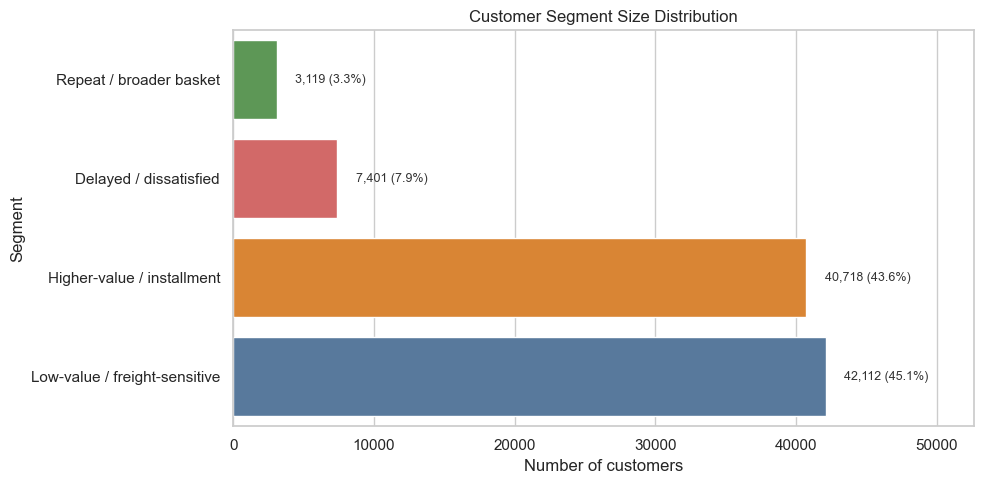

In [23]:
segment_size_plot_data = segment_profiles_visual.sort_values("customer_count", ascending=True).copy()

plt.figure(figsize=(10, 5))
ax = sns.barplot(
    data=segment_size_plot_data,
    x="customer_count",
    y="segment_short_name",
    hue="segment_name",
    palette=segment_color_map,
    legend=False,
)

for i, (_, row) in enumerate(segment_size_plot_data.iterrows()):
    ax.text(
        row["customer_count"] + 1300,
        i,
        f"{int(row['customer_count']):,} ({row['customer_share_pct']:.1f}%)",
        va="center",
        fontsize=9,
        color="#333333",
    )

ax.set_title("Customer Segment Size Distribution")
ax.set_xlabel("Number of customers")
ax.set_ylabel("Segment")
ax.set_xlim(0, segment_profiles_visual["customer_count"].max() * 1.25)
plt.tight_layout()
plt.savefig(figures_dir / "customer_segment_size_distribution.png", dpi=150, bbox_inches="tight")
plt.show()

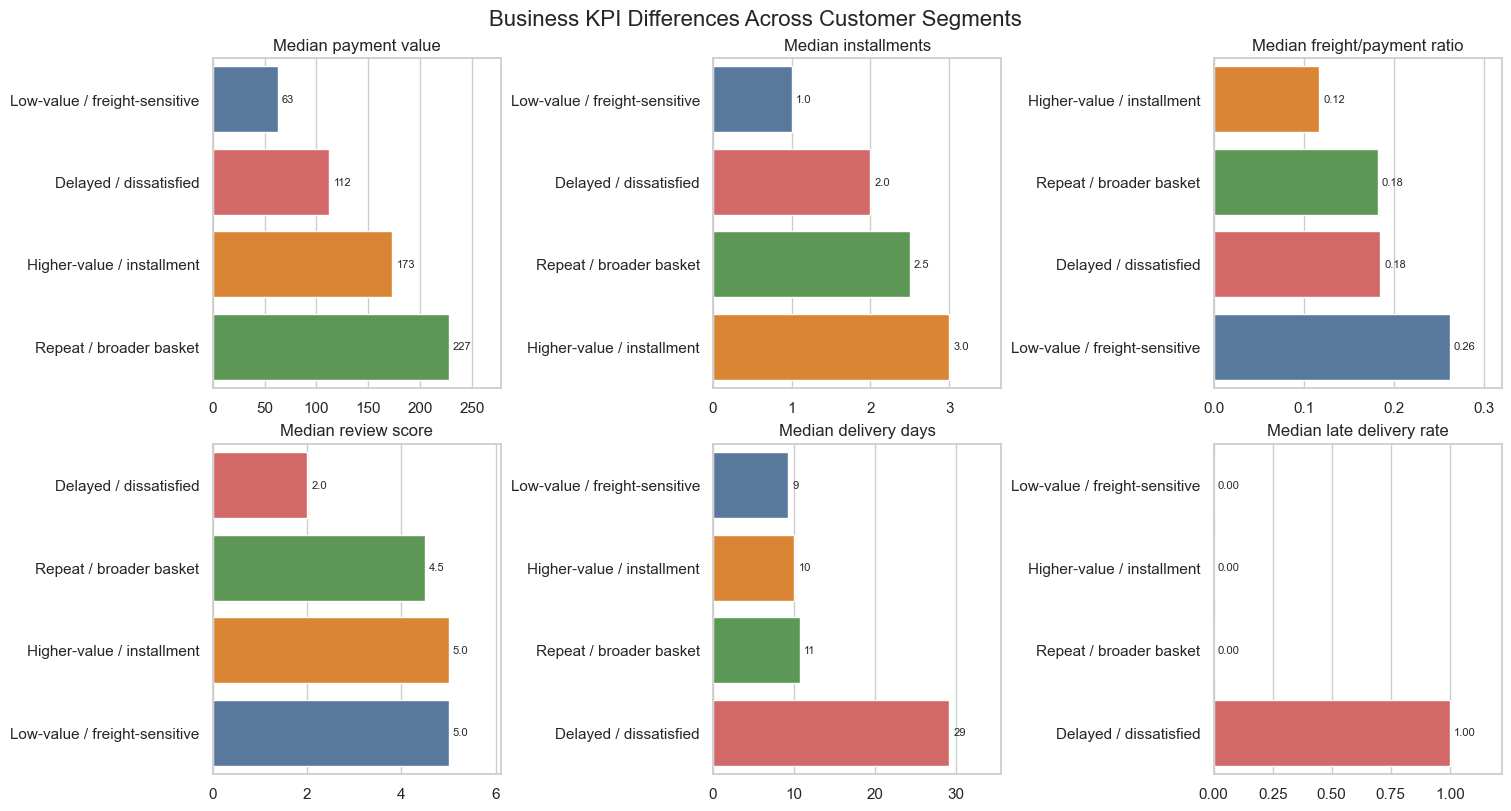

In [24]:
kpi_config = [
    ("total_payment_value", "Median payment value"),
    ("avg_payment_installments", "Median installments"),
    ("freight_to_payment_ratio", "Median freight/payment ratio"),
    ("avg_review_score", "Median review score"),
    ("avg_delivery_days", "Median delivery days"),
    ("late_delivery_rate", "Median late delivery rate"),
]

fig, axes = plt.subplots(2, 3, figsize=(15, 8), constrained_layout=True)

for ax, (column, title) in zip(axes.flat, kpi_config):
    kpi_plot_data = segment_profiles_visual.sort_values(column, ascending=True)
    sns.barplot(
        data=kpi_plot_data,
        x=column,
        y="segment_short_name",
        hue="segment_name",
        palette=segment_color_map,
        legend=False,
        ax=ax,
    )

    ax.set_title(title)
    ax.set_xlabel("")
    ax.set_ylabel("")

    max_value = max(kpi_plot_data[column].max(), 0.01)
    ax.set_xlim(0, max_value * 1.22)

    for container in ax.containers:
        labels = []
        for bar in container:
            value = bar.get_width()
            if column in ["late_delivery_rate", "freight_to_payment_ratio"]:
                labels.append(f"{value:.2f}")
            elif column in ["avg_review_score", "avg_payment_installments"]:
                labels.append(f"{value:.1f}")
            else:
                labels.append(f"{value:.0f}")
        ax.bar_label(container, labels=labels, padding=3, fontsize=8)

fig.suptitle("Business KPI Differences Across Customer Segments", fontsize=16)
fig.savefig(figures_dir / "customer_segment_business_kpi_summary.png", dpi=150, bbox_inches="tight")
plt.show()

## PCA Visualization

The model uses 10 scaled features. PCA is used only to visualize the high-dimensional feature matrix in two dimensions. It is not used to train the K-Means model in this notebook.

PCA explained variance ratio: [0.20560307 0.17747305]
Total explained variance in 2D: 0.38307611607262904


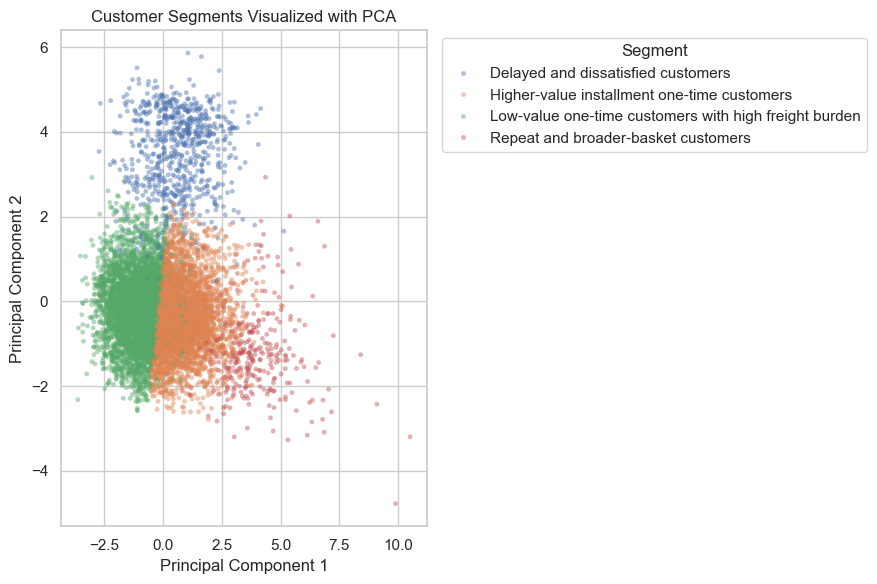

In [15]:
pca = PCA(n_components=2, random_state=RANDOM_STATE)
pca_components = pca.fit_transform(X)

pca_plot_data = pd.DataFrame(
    {
        "pc1": pca_components[:, 0],
        "pc2": pca_components[:, 1],
        "cluster": final_cluster_labels,
    }
)
pca_plot_data["segment_name"] = pca_plot_data["cluster"].map(segment_name_map)

pca_sample = pca_plot_data.sample(
    n=min(10_000, len(pca_plot_data)),
    random_state=RANDOM_STATE,
)

print("PCA explained variance ratio:", pca.explained_variance_ratio_)
print("Total explained variance in 2D:", pca.explained_variance_ratio_.sum())

plt.figure(figsize=(9, 6))
sns.scatterplot(
    data=pca_sample,
    x="pc1",
    y="pc2",
    hue="segment_name",
    s=12,
    alpha=0.45,
    linewidth=0,
)
plt.title("Customer Segments Visualized with PCA")
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.legend(title="Segment", bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()
plt.savefig(figures_dir / "customer_segments_pca.png", dpi=150, bbox_inches="tight")
plt.show()

## 3D PCA View

The 2D PCA chart only shows part of the variation in the scaled feature matrix. A 3D PCA view adds one more principal component and captures more information, so it can make the segment separation easier to see.

This chart is still a supporting visualization, not the main proof of clustering quality. The final K decision is based on metrics, cluster balance, and business interpretation.

PCA explained variance ratio (3D): [0.20560307 0.17747305 0.15990541]
Total explained variance in 3D: 0.5429815248825972


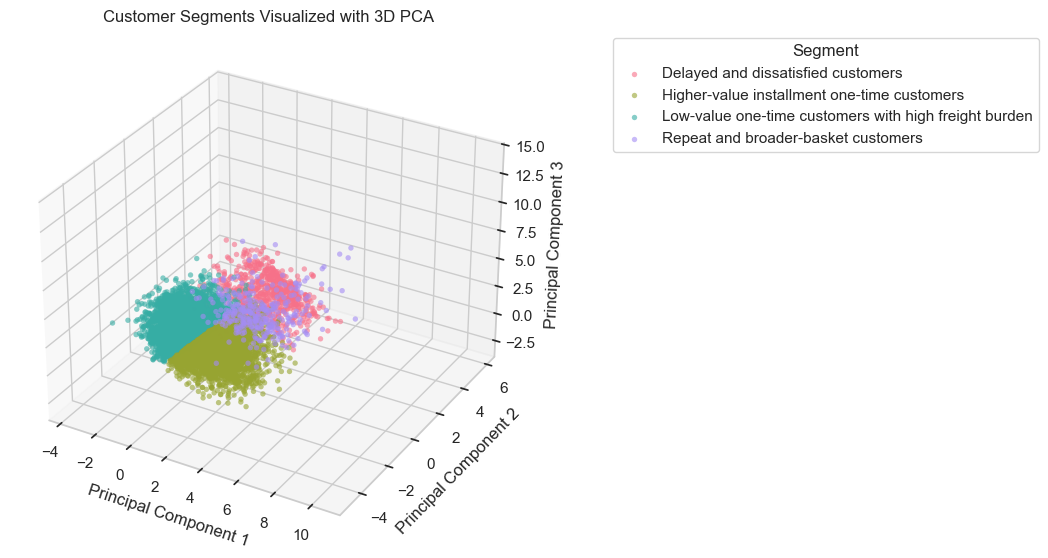

In [16]:
pca = PCA(n_components=3, random_state=RANDOM_STATE)
pca_components = pca.fit_transform(X)

pca_plot_data = pd.DataFrame(
    {
        "pc1": pca_components[:, 0],
        "pc2": pca_components[:, 1],
        "pc3": pca_components[:, 2],
        "cluster": final_cluster_labels,
    }
)
pca_plot_data["segment_name"] = pca_plot_data["cluster"].map(segment_name_map)

pca_sample = pca_plot_data.sample(
    n=min(10_000, len(pca_plot_data)),
    random_state=RANDOM_STATE,
)

print("PCA explained variance ratio (3D):", pca.explained_variance_ratio_)
print("Total explained variance in 3D:", pca.explained_variance_ratio_.sum())

fig = plt.figure(figsize=(10, 8))
ax = fig.add_subplot(111, projection='3d')

segments = pca_sample["segment_name"].unique()
colors = sns.color_palette("husl", len(segments))

for i, segment in enumerate(segments):
    subset = pca_sample[pca_sample["segment_name"] == segment]
    ax.scatter(
        subset["pc1"],
        subset["pc2"],
        subset["pc3"],
        label=segment,
        s=15,
        alpha=0.6,
        linewidth=0,
        color=colors[i]
    )

ax.set_title("Customer Segments Visualized with 3D PCA")
ax.set_xlabel("Principal Component 1")
ax.set_ylabel("Principal Component 2")
ax.set_zlabel("Principal Component 3")
ax.legend(title="Segment", bbox_to_anchor=(1.15, 1), loc="upper left")

plt.tight_layout()
plt.savefig(figures_dir / "customer_segments_pca_3d.png", dpi=150, bbox_inches="tight")
plt.show()

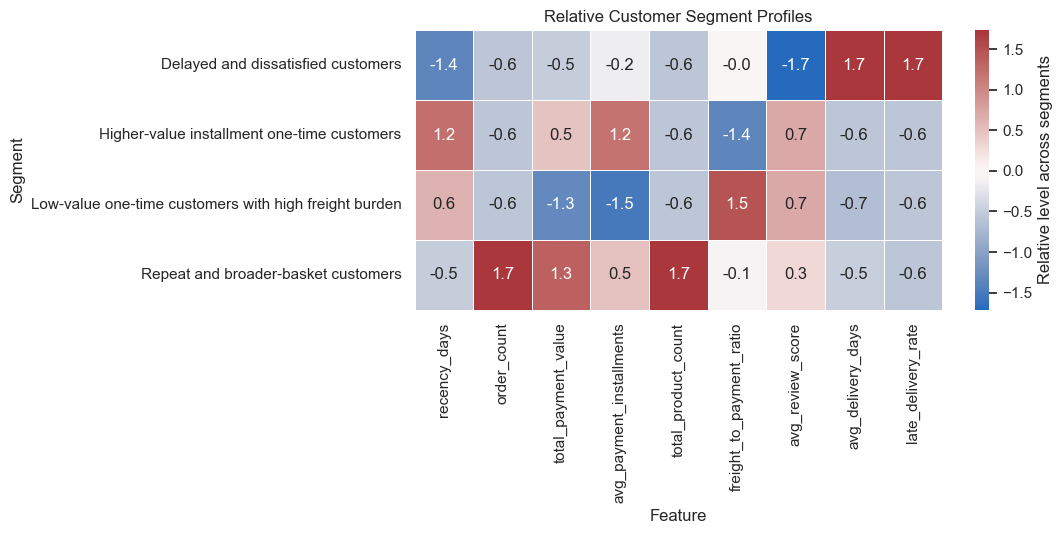

In [17]:
profile_heatmap = (
    segment_profile_data
    .groupby("segment_name")[business_profile_columns]
    .median()
)

profile_heatmap_scaled = (
    profile_heatmap - profile_heatmap.mean()
) / profile_heatmap.std(ddof=0)

plt.figure(figsize=(11, 5.5))
sns.heatmap(
    profile_heatmap_scaled,
    cmap="vlag",
    center=0,
    annot=True,
    fmt=".1f",
    linewidths=0.4,
    cbar_kws={"label": "Relative level across segments"},
)
plt.title("Relative Customer Segment Profiles")
plt.xlabel("Feature")
plt.ylabel("Segment")
plt.tight_layout()
plt.savefig(figures_dir / "customer_segment_profile_heatmap.png", dpi=150, bbox_inches="tight")
plt.show()

## Save Modeling Outputs

The evaluation metrics, final customer segment labels, and segment profiles are saved locally as processed outputs. These files are ignored by Git and can be reproduced by rerunning the notebook.

In [18]:
evaluation_metrics_path = processed_data_dir / "kmeans_evaluation_metrics.csv"
customer_segments_path = processed_data_dir / "customer_segments_kmeans.csv"
segment_profiles_path = processed_data_dir / "customer_segment_profiles.csv"

evaluation_metrics.to_csv(evaluation_metrics_path, index=False)
customer_segments.to_csv(customer_segments_path, index=False)
segment_profiles.to_csv(segment_profiles_path, index=False)

print("Saved evaluation metrics to:", evaluation_metrics_path)
print("Saved customer segments to:", customer_segments_path)
print("Saved segment profiles to:", segment_profiles_path)

Saved evaluation metrics to: d:\Workspace\Tugas_IMV_Laboratory_Recruitment\imv-customer-segmentation-kmeans\data\processed\kmeans_evaluation_metrics.csv
Saved customer segments to: d:\Workspace\Tugas_IMV_Laboratory_Recruitment\imv-customer-segmentation-kmeans\data\processed\customer_segments_kmeans.csv
Saved segment profiles to: d:\Workspace\Tugas_IMV_Laboratory_Recruitment\imv-customer-segmentation-kmeans\data\processed\customer_segment_profiles.csv


## Save Report-Ready Tables

Small Markdown tables are saved to `reports/tables`. These files are useful for HackMD and presentation drafting. They are not raw data; they are compact reporting artifacts.

In [25]:
reports_tables_dir = project_root / "reports" / "tables"
reports_tables_dir.mkdir(parents=True, exist_ok=True)


def dataframe_to_markdown_table(df):
    formatted = df.copy()

    for column in formatted.columns:
        if pd.api.types.is_float_dtype(formatted[column]):
            formatted[column] = formatted[column].map(lambda value: f"{value:.4f}")
        elif pd.api.types.is_integer_dtype(formatted[column]):
            formatted[column] = formatted[column].map(lambda value: f"{int(value)}")
        else:
            formatted[column] = formatted[column].astype(str)

    columns = list(formatted.columns)
    lines = []
    lines.append("| " + " | ".join(columns) + " |")
    lines.append("| " + " | ".join(["---"] * len(columns)) + " |")

    for _, row in formatted.iterrows():
        lines.append("| " + " | ".join(row[column] for column in columns) + " |")

    return "\n".join(lines) + "\n"


table_outputs = {
    "kmeans_evaluation_metrics.md": evaluation_metrics.round(4),
    "customer_segment_profiles.md": segment_profiles_visual.round(4),
    "segment_interpretation.md": segment_interpretation,
}

for file_name, table_df in table_outputs.items():
    output_path = reports_tables_dir / file_name
    output_path.write_text(dataframe_to_markdown_table(table_df), encoding="utf-8")
    print("Saved report table:", output_path)

Saved report table: d:\Workspace\Tugas_IMV_Laboratory_Recruitment\imv-customer-segmentation-kmeans\reports\tables\kmeans_evaluation_metrics.md
Saved report table: d:\Workspace\Tugas_IMV_Laboratory_Recruitment\imv-customer-segmentation-kmeans\reports\tables\customer_segment_profiles.md
Saved report table: d:\Workspace\Tugas_IMV_Laboratory_Recruitment\imv-customer-segmentation-kmeans\reports\tables\segment_interpretation.md


## K-Means Modeling Summary

This notebook evaluated K-Means cluster counts from K=2 to K=8 and selected K=4 as the final segmentation solution.

Main findings:

- K=2 had the highest silhouette score, but it was too imbalanced because most customers were assigned to one cluster.
- K=4 provided a better balance between cluster size and business interpretability.
- The final four segments are:
  - Low-value one-time customers with high freight burden.
  - Higher-value installment one-time customers.
  - Delayed and dissatisfied customers.
  - Repeat and broader-basket customers.

Additional reporting outputs:

- Segment size distribution chart.
- Business KPI comparison chart.
- 2D and 3D PCA supporting visualizations.
- Report-ready Markdown tables for documentation and presentation drafting.

The next step is to turn the notebook results into final project documentation, presentation slides, and a concise video explanation.